In [2]:
import pandas as pd
import numpy as np
import plotly.express as px

In [6]:
cards_df = pd.read_csv('./data/cards_clustered.csv')
decks_df = pd.read_csv('./data/decks.csv')

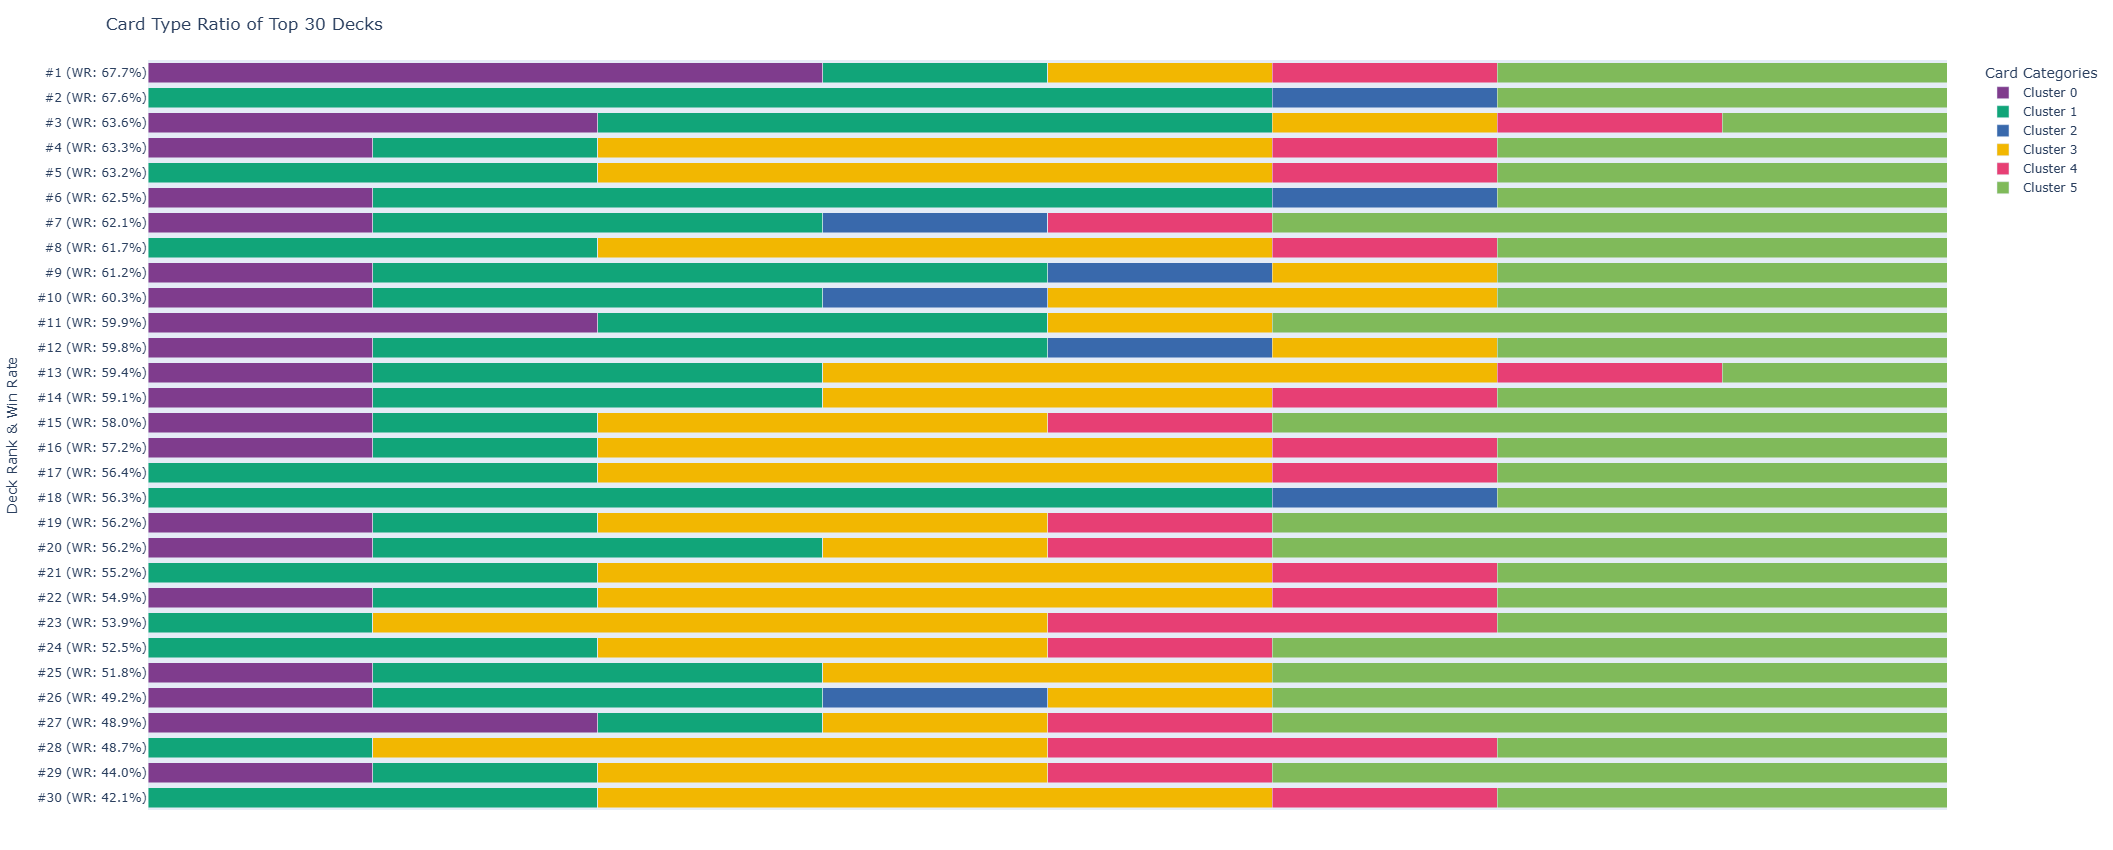

In [22]:
# Bar Chart of Deck Ratios
card_to_cluster = dict(zip(cards_df['name'], cards_df['Cluster']))
deck_clusters = decks_df.iloc[:, :8].map(lambda x: card_to_cluster.get(x, np.nan))

cluster_counts = deck_clusters.apply(lambda row: row.value_counts(), axis=1).fillna(0).astype(int)
cluster_counts = cluster_counts.reindex(columns=sorted(cluster_counts.columns))
cluster_counts.columns = [f"Cluster {int(c)}" for c in cluster_counts.columns]

cluster_ratios = cluster_counts.div(8)

decks_sorted = decks.sort_values(by='Win Rate', ascending=False).reset_index(drop=True)
cluster_ratios['Deck'] = [f"#{i+1} (WR: {row['Win Rate']}%)" for i, row in decks_sorted.iterrows()]

df_long = cluster_ratios.melt(id_vars='Deck', var_name='Cluster', value_name='Ratio')

fig = px.bar(
    df_long, 
    x='Ratio', 
    y='Deck', 
    color='Cluster', 
    orientation='h',
    title='Card Type Ratio of Top 30 Decks',
    labels={'Deck': 'Deck Rank & Win Rate'},
    category_orders={'Deck': cluster_ratios['Deck']} ,
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_layout(
    barmode='stack',
    height=850,
    xaxis=dict(visible=False, range=[0, 1]),
    margin=dict(l=120, r=40, t=60, b=40),
    legend_title_text='Card Categories',
    hovermode='y unified'
)

#fig.write_html('./graphs/card_type_ratio.html')
fig.show()